## Análisis tipo 'John Snow'

#### 1. El Análisis de John Snow sobre el Cólera (1854)

John Snow, un médico británico, es ampliamente reconocido como uno de los padres de la epidemiología moderna por su investigación sobre la epidemia de cólera en Londres de 1854. En un momento en que la teoría miasmática (que atribuía las enfermedades a "mal aire") era la dominante, Snow propuso que el cólera se transmitía a través del agua contaminada. Su metodología fue revolucionaria:

*   **Mapeo de Casos:** Snow mapeó meticulosamente los casos de cólera en el distrito de Soho, Londres. Cada punto en su mapa representaba la dirección de una víctima de cólera.
*   **Identificación de Fuentes de Agua:** Superpuso la ubicación de las bombas de agua públicas en el mismo mapa.
*   **Análisis Geográfico:** Al observar el patrón de los casos, notó una clara concentración de muertes alrededor de la bomba de agua de Broad Street. También observó que las personas que vivían lejos de esta bomba, pero que la usaban, enfermaban, mientras que aquellos que vivían cerca pero utilizaban otras fuentes de agua (como los trabajadores de una cervecería que bebían cerveza en lugar de agua de la calle) no lo hacían.
*   **Hipótesis:** Basándose en esta evidencia geográfica, Snow concluyó que la bomba de Broad Street era la fuente de la contaminación.
*   **Intervención:** Su persuasión llevó a la remoción del mango de la bomba, lo que se considera un punto de inflexión en la contención de la epidemia en esa zona. Posteriormente, se descubrió que un pozo negro cercano estaba filtrando desechos fecales hacia el pozo de la bomba.

El trabajo de Snow demostró la importancia de la observación empírica, el análisis espacial y la recopilación sistemática de datos para comprender y controlar las enfermedades.

#### 2. Analogía con `df_multivariante`

El conjunto de datos `df_multivariante` presenta una excelente oportunidad para emular el tipo de análisis espacial y de causa-efecto que realizó John Snow. Consideremos las variables clave:

*   **`COORD_X` y `COORD_Y`:** Estas variables representan las coordenadas geográficas de cada "casa" o unidad de observación. Son directamente análogas a las direcciones que John Snow mapeó para ubicar los casos de cólera. Permitirían visualizar la distribución espacial de las muertes y otras variables.
*   **`deaths`:** Esta columna registra el número total de muertes en cada ubicación. Es el equivalente directo a los casos de cólera que Snow registró. El objetivo sería ver cómo estas muertes se agrupan geográficamente.
*   **`dis_bspump`:** Esta variable mide la distancia a la bomba principal de Broad Street. Es crucial, ya que John Snow utilizó la proximidad a las bombas de agua como un indicador clave de exposición.
*   **`dis_sewers`:** Esta variable, que mide la distancia a las alcantarillas, es otra pieza de información crítica. John Snow investigó la infraestructura de saneamiento y cómo los pozos negros contaminaban las fuentes de agua.
*   **`dis_pestf`:** Esta variable  mide la distancia al campo de pestes.
*   **`pestfield`:** Variable que indica si la casa estaba construida encima del pest field.

## Cargar Datos de Ejemplo


In [1]:
import numpy as np
import pandas as pd
np.set_printoptions(suppress=True, precision=3, linewidth=100)
df_multivariante = pd.read_csv("reliability_class_3.csv")
df_multivariante.head(10)

,ID,deaths_r,deaths_nr,deaths,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
0,1,0,0,0,1,10.08,10.08,125.00,0,529286.397349,181084.117357
1,2,1,0,1,1,14.64,14.64,119.94,1,529289.814976,181079.748106
2,3,0,0,0,1,18.47,18.47,116.27,0,529291.730637,181075.340644
3,4,0,0,0,1,22.98,22.98,112.56,0,529293.511415,181070.327564
4,5,0,0,0,1,27.47,27.47,109.10,0,529295.355045,181065.797833
5,6,5,0,5,1,32.21,32.21,105.54,1,529297.423976,181061.273836
6,7,1,0,1,1,42.77,42.77,101.43,1,529300.171861,181056.646676
7,8,0,0,0,1,36.43,36.43,97.56,0,529302.427745,181050.682183
8,9,0,0,0,1,31.48,31.48,94.08,0,529304.872182,181046.167742
9,10,0,0,0,1,32.31,32.31,112.86,0,529286.446605,181000.330925


In [2]:
df_multivariante.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852 entries, 0 to 1851
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          1852 non-null   int64  
 1   deaths_r    1852 non-null   int64  
 2   deaths_nr   1852 non-null   int64  
 3   deaths      1852 non-null   int64  
 4   pestfield   1852 non-null   int64  
 5   dis_pestf   1852 non-null   float64
 6   dis_sewers  1852 non-null   float64
 7   dis_bspump  1852 non-null   float64
 8   death_dum   1852 non-null   int64  
 9   COORD_X     1852 non-null   float64
 10  COORD_Y     1852 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 159.3 KB


In [3]:
df_multivariante.describe()

,ID,deaths_r,deaths_nr,deaths,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
count,1852.000000,1852.000000,1852.000000,1852.000000,1852.000000,1852.000000,1852.000000,1852.000000,1852.000000,1852.000000,1852.000000
mean,926.500000,0.356911,0.024298,0.381210,0.049136,173.734114,19.393537,206.208326,0.199244,529370.988452,181004.473694
std,534.770667,0.950726,0.457784,1.060785,0.216210,87.826565,11.043473,81.429081,0.399540,156.676767,153.408305
min,1.000000,0.000000,0.000000,0.000000,0.000000,7.560000,2.850000,7.260000,0.000000,528996.140463,180646.889176
25%,463.750000,0.000000,0.000000,0.000000,0.000000,106.932500,11.127500,149.205000,0.000000,529247.048322,180892.239379
50%,926.500000,0.000000,0.000000,0.000000,0.000000,177.170000,17.035000,203.730000,0.000000,529385.768418,181005.009311
75%,1389.250000,0.000000,0.000000,0.000000,0.000000,237.942500,24.690000,260.602500,0.000000,529500.029260,181131.801616
max,1852.000000,12.000000,18.000000,18.000000,1.000000,441.340000,92.400000,442.990000,1.000000,529696.169503,181319.852323


## Normalización


In [ ]:
# Normalization of the data

df_norm.head(10)

,ID,deaths_r,deaths_nr,deaths,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
0,0.000000,0.000000,0.0,0.000000,1.0,0.005809,0.080737,0.270213,0.0,0.414635,0.649706
1,0.000540,0.083333,0.0,0.055556,1.0,0.016322,0.131658,0.258601,1.0,0.419518,0.643213
2,0.001080,0.000000,0.0,0.000000,1.0,0.025151,0.174428,0.250178,0.0,0.422254,0.636664
3,0.001621,0.000000,0.0,0.000000,1.0,0.035548,0.224791,0.241663,0.0,0.424798,0.629215
4,0.002161,0.000000,0.0,0.000000,1.0,0.045899,0.274930,0.233723,0.0,0.427432,0.622484
5,0.002701,0.416667,0.0,0.277778,1.0,0.056826,0.327862,0.225553,1.0,0.430387,0.615761
6,0.003241,0.083333,0.0,0.055556,1.0,0.081170,0.445784,0.216120,1.0,0.434313,0.608885
7,0.003782,0.000000,0.0,0.000000,1.0,0.066554,0.374986,0.207238,0.0,0.437535,0.600022
8,0.004322,0.000000,0.0,0.000000,1.0,0.055143,0.319710,0.199252,0.0,0.441027,0.593314
9,0.004862,0.000000,0.0,0.000000,1.0,0.057057,0.328978,0.242352,0.0,0.414706,0.525202


In [ ]:
#Normalization 

df_norm.head(10)

,ID,deaths_r,deaths_nr,deaths,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
0,-1.730648,-0.375409,-0.053078,-0.359365,4.397863,-1.863378,-0.843352,-0.997289,-0.498684,-0.539908,0.519161
1,-1.728778,0.676418,-0.053078,0.583332,4.397863,-1.811458,-0.430439,-1.059429,2.004196,-0.518095,0.490680
2,-1.726908,-0.375409,-0.053078,-0.359365,4.397863,-1.767849,-0.083627,-1.104499,-0.498684,-0.505868,0.461950
3,-1.725039,-0.375409,-0.053078,-0.359365,4.397863,-1.716498,0.324759,-1.150060,-0.498684,-0.494502,0.429272
4,-1.723169,-0.375409,-0.053078,-0.359365,4.397863,-1.665374,0.731334,-1.192551,-0.498684,-0.482735,0.399745
5,-1.721299,4.883730,-0.053078,4.354124,4.397863,-1.611404,1.160546,-1.236270,2.004196,-0.469530,0.370255
6,-1.719429,0.676418,-0.053078,0.583332,4.397863,-1.491167,2.116767,-1.286743,2.004196,-0.451992,0.340092
7,-1.717559,-0.375409,-0.053078,-0.359365,4.397863,-1.563355,1.542673,-1.334269,-0.498684,-0.437593,0.301212
8,-1.715689,-0.375409,-0.053078,-0.359365,4.397863,-1.619716,1.094444,-1.377006,-0.498684,-0.421992,0.271785
9,-1.713819,-0.375409,-0.053078,-0.359365,4.397863,-1.610266,1.169602,-1.146376,-0.498684,-0.539594,-0.027005


In [6]:
df_norm.describe()

,ID,deaths_r,deaths_nr,deaths,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
count,1852.000000,1.852000e+03,1852.000000,1852.000000,1.852000e+03,1.852000e+03,1.852000e+03,1.852000e+03,1.852000e+03,1.852000e+03,1.852000e+03
mean,0.000000,-3.069299e-17,0.000000,0.000000,1.534650e-17,-9.207897e-17,6.905923e-17,6.138598e-17,-1.534650e-17,2.483063e-13,6.360355e-14
std,1.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.730648,-3.754094e-01,-0.053078,-0.359365,-2.272604e-01,-1.892071e+00,-1.498037e+00,-2.443210e+00,-4.986839e-01,-2.392492e+00,-2.330933e+00
25%,-0.865324,-3.754094e-01,-0.053078,-0.359365,-2.272604e-01,-7.606083e-01,-7.484997e-01,-7.000365e-01,-4.986839e-01,-7.910562e-01,-7.316052e-01
50%,0.000000,-3.754094e-01,-0.053078,-0.359365,-2.272604e-01,3.912126e-02,-2.135684e-01,-3.043539e-02,-4.986839e-01,9.433412e-02,3.491447e-03
75%,0.865324,-3.754094e-01,-0.053078,-0.359365,-2.272604e-01,7.310816e-01,4.796012e-01,6.679944e-01,-4.986839e-01,8.236116e-01,8.299937e-01
max,1.730648,1.224652e+01,39.266798,16.609197,4.397863e+00,3.046981e+00,6.610824e+00,2.907827e+00,2.004196e+00,2.075490e+00,2.055812e+00


## Calcular Vector de Medias



In [ ]:
#Calculate the mean vector

print("Vector de Medias:\n", mean_vector)

Vector de Medias:
 ID               926.500000
deaths_r           0.356911
deaths_nr          0.024298
deaths             0.381210
pestfield          0.049136
dis_pestf        173.734114
dis_sewers        19.393537
dis_bspump       206.208326
death_dum          0.199244
COORD_X       529370.988452
COORD_Y       181004.473694
dtype: float64


## Calcular Matriz de Datos Centrados

In [ ]:
#Calculate the centered data matrix

print("Matriz de Datos Centrados (primeras 5 filas):")
df_centrado.head()

Matriz de Datos Centrados (primeras 5 filas):


,ID,deaths_r,deaths_nr,deaths,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
0,-925.5,-0.356911,-0.024298,-0.38121,0.950864,-163.654114,-9.313537,-81.208326,-0.199244,-84.591103,79.643663
1,-924.5,0.643089,-0.024298,0.61879,0.950864,-159.094114,-4.753537,-86.268326,0.800756,-81.173477,75.274411
2,-923.5,-0.356911,-0.024298,-0.38121,0.950864,-155.264114,-0.923537,-89.938326,-0.199244,-79.257815,70.866950
3,-922.5,-0.356911,-0.024298,-0.38121,0.950864,-150.754114,3.586463,-93.648326,-0.199244,-77.477038,65.853869
4,-921.5,-0.356911,-0.024298,-0.38121,0.950864,-146.264114,8.076463,-97.108326,-0.199244,-75.633407,61.324139


## Calcular Matriz de Covarianzas


In [ ]:
#Calculate the covariance matrix

print("Matriz de Covarianzas:")
print(cov_matrix)

Matriz de Covarianzas:
                       ID   deaths_r  deaths_nr     deaths  pestfield  \
ID          285979.666667  45.229335   4.059697  49.289033 -43.287682   
deaths_r        45.229335   0.903880   0.005910   0.909790   0.031076   
deaths_nr        4.059697   0.005910   0.209566   0.215476  -0.000654   
deaths          49.289033   0.909790   0.215476   1.125265   0.030421   
pestfield      -43.287682   0.031076  -0.000654   0.030421   0.046747   
dis_pestf    23420.926240 -12.408995  -1.678247 -14.087242  -7.300170   
dis_sewers    -809.458625  -0.148573   0.008099  -0.140474   0.265223   
dis_bspump   -8096.623663 -27.826398  -3.249916 -31.076315  -5.280863   
death_dum       29.279579   0.285953   0.019467   0.305421   0.012895   
COORD_X      62983.960054  20.665288   1.181403  21.846691  -3.270871   
COORD_Y      14968.078627   7.172874   0.656004   7.828878   1.000003   

               dis_pestf  dis_sewers   dis_bspump  death_dum       COORD_X  \
ID          23420.9262

In [ ]:
#Calculate the covariance matrix using the centered data

m_cov

,ID,deaths_r,deaths_nr,deaths,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
ID,285979.666667,45.229335,4.059697,49.289033,-43.287682,23420.926240,-809.458625,-8096.623663,29.279579,62983.960054,14968.078627
deaths_r,45.229335,0.903880,0.005910,0.909790,0.031076,-12.408995,-0.148573,-27.826398,0.285953,20.665288,7.172874
deaths_nr,4.059697,0.005910,0.209566,0.215476,-0.000654,-1.678247,0.008099,-3.249916,0.019467,1.181403,0.656004
deaths,49.289033,0.909790,0.215476,1.125265,0.030421,-14.087242,-0.140474,-31.076315,0.305421,21.846691,7.828878
pestfield,-43.287682,0.031076,-0.000654,0.030421,0.046747,-7.300170,0.265223,-5.280863,0.012895,-3.270871,1.000003
dis_pestf,23420.926240,-12.408995,-1.678247,-14.087242,-7.300170,7713.505562,-76.008558,4135.655861,-5.569140,8035.316572,-1950.243616
dis_sewers,-809.458625,-0.148573,0.008099,-0.140474,0.265223,-76.008558,121.958301,-37.298372,0.014795,-204.070304,105.152331
dis_bspump,-8096.623663,-27.826398,-3.249916,-31.076315,-5.280863,4135.655861,-37.298372,6630.695168,-13.722405,-3241.806567,-1147.693587
death_dum,29.279579,0.285953,0.019467,0.305421,0.012895,-5.569140,0.014795,-13.722405,0.159632,12.050411,3.617005
COORD_X,62983.960054,20.665288,1.181403,21.846691,-3.270871,8035.316572,-204.070304,-3241.806567,12.050411,24547.609244,-5339.719894


## Calcular Coeficientes de Correlación



In [ ]:
#Calculate the correlation matrix

print("Matriz de Correlación:")
print(correlation_matrix)

Matriz de Correlación:
                  ID  deaths_r  deaths_nr    deaths  pestfield  dis_pestf  \
ID          1.000000  0.088961   0.016583  0.086887  -0.374386   0.498667   
deaths_r    0.088961  1.000000   0.013579  0.902107   0.151178  -0.148613   
deaths_nr   0.016583  0.013579   1.000000  0.443722  -0.006611  -0.041742   
deaths      0.086887  0.902107   0.443722  1.000000   0.132640  -0.151207   
pestfield  -0.374386  0.151178  -0.006611  0.132640   1.000000  -0.384442   
dis_pestf   0.498667 -0.148613  -0.041742 -0.151207  -0.384442   1.000000   
dis_sewers -0.137063 -0.014151   0.001602 -0.011991   0.111078  -0.078367   
dis_bspump -0.185933 -0.359436  -0.087183 -0.359768  -0.299950   0.578281   
death_dum   0.137037  0.752800   0.106435  0.720628   0.149275  -0.158709   
COORD_X     0.751723  0.138734   0.016471  0.131448  -0.096557   0.583946   
COORD_Y     0.182452  0.049180   0.009341  0.048109   0.030149  -0.144749   

            dis_sewers  dis_bspump  death_dum   COOR

## Variables redundantes

In [12]:
import scipy.linalg as la
df_numpy = m_cov.to_numpy()
val_prop, vect_prop = la.eigh(df_numpy)
print("Valores Propios:")
print(val_prop)

Valores Propios:
[     0.         0.027      0.06       0.294      1.724    113.137    328.435   6357.289  10533.662
  27918.844 303276.516]


In [13]:
valores,vectores=np.linalg.eig(df_numpy)
print("Valores Propios:")
print(valores)

Valores Propios:
[303276.516  27918.844  10533.662   6357.289    328.435    113.137      1.724      0.294      0.06
      0.027     -0.   ]


In [14]:
print("Vectores Propios:")
print(vect_prop)

Vectores Propios:
[[ 0.     0.    -0.    -0.    -0.    -0.005  0.001  0.231  0.008 -0.072  0.97 ]
 [-0.577 -0.012  0.179 -0.473 -0.641  0.005 -0.006 -0.001 -0.003 -0.     0.   ]
 [-0.577  0.011 -0.063  0.809 -0.094  0.001 -0.001 -0.    -0.    -0.     0.   ]
 [ 0.577 -0.001  0.116  0.336 -0.735  0.005 -0.007 -0.001 -0.003 -0.     0.   ]
 [-0.     1.     0.003 -0.015 -0.007 -0.001  0.002 -0.001 -0.001 -0.    -0.   ]
 [ 0.     0.002 -0.    -0.     0.005  0.108 -0.692 -0.303  0.614  0.185  0.082]
 [-0.    -0.001  0.    -0.    -0.006 -0.988 -0.156 -0.009 -0.004 -0.005 -0.003]
 [ 0.    -0.001 -0.001  0.    -0.01  -0.102  0.627  0.098  0.764  0.043 -0.028]
 [ 0.     0.    -0.975 -0.1   -0.2    0.001 -0.002 -0.001 -0.001 -0.     0.   ]
 [-0.    -0.002  0.     0.    -0.001 -0.045  0.319 -0.788 -0.184  0.44   0.221]
 [-0.    -0.001  0.     0.     0.     0.001  0.046 -0.474  0.075 -0.875  0.047]]


In [15]:
vect_prop_null= vect_prop[:,0]
vect_prop_null = vect_prop_null / np.max(vect_prop_null)
print(df_centrado.columns.tolist())
vect_prop_null

['ID', 'deaths_r', 'deaths_nr', 'deaths', 'pestfield', 'dis_pestf', 'dis_sewers', 'dis_bspump', 'death_dum', 'COORD_X', 'COORD_Y']


array([ 0., -1., -1.,  1., -0.,  0., -0.,  0.,  0., -0., -0.])

 deaths - deaths_r - deaths_nr = 0





In [16]:
df_centrado = df_centrado.drop(['ID','deaths'], axis=1)
df_centrado.head(10)

,deaths_r,deaths_nr,pestfield,dis_pestf,dis_sewers,dis_bspump,death_dum,COORD_X,COORD_Y
0,-0.356911,-0.024298,0.950864,-163.654114,-9.313537,-81.208326,-0.199244,-84.591103,79.643663
1,0.643089,-0.024298,0.950864,-159.094114,-4.753537,-86.268326,0.800756,-81.173477,75.274411
2,-0.356911,-0.024298,0.950864,-155.264114,-0.923537,-89.938326,-0.199244,-79.257815,70.866950
3,-0.356911,-0.024298,0.950864,-150.754114,3.586463,-93.648326,-0.199244,-77.477038,65.853869
4,-0.356911,-0.024298,0.950864,-146.264114,8.076463,-97.108326,-0.199244,-75.633407,61.324139
5,4.643089,-0.024298,0.950864,-141.524114,12.816463,-100.668326,0.800756,-73.564477,56.800142
6,0.643089,-0.024298,0.950864,-130.964114,23.376463,-104.778326,0.800756,-70.816591,52.172981
7,-0.356911,-0.024298,0.950864,-137.304114,17.036463,-108.648326,-0.199244,-68.560708,46.208489
8,-0.356911,-0.024298,0.950864,-142.254114,12.086463,-112.128326,-0.199244,-66.116271,41.694048
9,-0.356911,-0.024298,0.950864,-141.424114,12.916463,-93.348326,-0.199244,-84.541847,-4.142769


## Calcular Distancia Euclidiana


In [17]:
from sklearn.metrics.pairwise import euclidean_distances
euclidean_dist_matrix_1 = euclidean_distances(df_centrado)
print("Matriz de distancias euclidianas:")
pd.DataFrame(euclidean_dist_matrix_1)

Matriz de distancias euclidianas:


,0,1,2,3,4,5,6,7,8,9,...,1842,1843,1844,1845,1846,1847,1848,1849,1850,1851
0,0.000000,9.998066,17.957498,26.987811,35.685844,45.028639,60.325721,59.299941,60.443851,90.309988,...,375.276646,375.779425,355.466598,366.033672,392.984761,399.727289,402.442846,498.675592,536.789971,560.784364
1,9.998066,0.000000,8.240277,17.262267,25.962008,35.213141,50.657231,49.561905,50.914350,83.636228,...,370.105087,370.516868,350.037165,360.666851,387.438047,394.256586,396.789561,493.367526,531.729901,555.835220
2,17.957498,8.240277,0.000000,9.096508,17.821630,27.367815,42.707427,41.444603,43.065935,77.775949,...,366.462484,366.784995,346.187482,356.852417,383.360209,390.246355,392.431195,489.142362,527.652877,551.879721
3,26.987811,17.262267,9.096508,0.000000,8.729790,18.518756,33.774152,32.438356,34.623322,71.579527,...,362.636383,362.854115,342.148036,352.839079,379.003654,385.960837,387.723686,484.488013,523.141551,547.503289
4,35.685844,25.962008,17.821630,8.729790,0.000000,10.409410,25.218134,23.921554,27.086472,66.530183,...,358.954920,359.072915,338.276540,348.986682,374.823293,381.842098,383.259152,480.050389,518.845659,543.320470
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1847,399.727289,394.256586,390.246355,385.960837,381.842098,377.628715,370.106387,371.691808,372.804208,378.758767,...,47.554732,42.236986,58.037490,47.532040,9.116191,0.000000,75.810564,153.150195,196.078174,207.702643
1848,402.442846,396.789561,392.431195,387.723686,383.259152,378.724564,371.335829,371.496414,371.569857,367.722525,...,112.874752,107.777310,111.759043,106.804094,71.135989,75.810564,0.000000,110.008899,152.945337,173.760955
1849,498.675592,493.367526,489.142362,484.488013,480.050389,475.516757,467.862998,468.547588,469.063428,459.231681,...,198.021392,193.507910,206.556124,197.761260,154.644525,153.150195,110.008899,0.000000,45.744460,66.850512
1850,536.789971,531.729901,527.652877,523.141551,518.845659,514.459482,507.096171,507.670079,508.117423,495.963777,...,239.727600,235.610470,249.450500,240.395175,198.078832,196.078174,152.945337,45.744460,0.000000,31.358969


In [18]:
from sklearn.metrics.pairwise import euclidean_distances
euclidean_dist_matrix = euclidean_distances(df_centrado.T)
print("Matriz de distancias euclidianas:")
pd.DataFrame(euclidean_dist_matrix)

Matriz de distancias euclidianas:


,0,1,2,3,4,5,6,7,8
0,0.000000,45.156507,40.553274,3784.879123,477.459854,3518.252857,30.165562,6735.190784,6598.238636
1,45.156507,0.000000,21.837066,3779.457576,475.502619,3505.115669,24.724836,6740.447987,6599.969195
2,40.553274,21.837066,0.000000,3782.170085,474.182969,3506.145040,18.283052,6741.648167,6599.849885
3,3784.879123,3779.457576,3782.170085,0.000000,3845.104328,3352.747761,3781.350451,5474.356725,8065.924290
4,477.459854,475.502619,474.182969,3845.104328,0.000000,3554.889611,475.379348,6813.137147,6587.723801
5,3518.252857,3505.115669,3506.145040,3352.747761,3554.889611,0.000000,3510.628516,8349.383772,7751.374872
6,30.165562,24.724836,18.283052,3781.350451,475.379348,3510.628516,0.000000,6737.455719,6599.131709
7,6735.190784,6740.447987,6741.648167,5474.356725,6813.137147,8349.383772,6737.455719,0.000000,10429.137153
8,6598.238636,6599.969195,6599.849885,8065.924290,6587.723801,7751.374872,6599.131709,10429.137153,0.000000


La **Distancia Euclidiana** es la forma más común de medir la distancia entre dos puntos en un espacio euclidiano. En el contexto de los datos multivariantes, se calcula como la raíz cuadrada de la suma de los cuadrados de las diferencias entre las coordenadas correspondientes de dos observaciones. En esencia, mide la "distancia en línea recta" entre dos observaciones en un espacio multidimensional.

**Características clave de la Distancia Euclidiana:**
*   **Sensibilidad a la escala:** Si las variables tienen escalas muy diferentes, aquellas con rangos más grandes dominarán el cálculo de la distancia. Por ejemplo, si una variable varía de 0 a 1000 y otra de 0 a 1, la primera tendrá un impacto mucho mayor en la distancia.
*   **No considera correlaciones:** Trata cada variable como independiente, sin tener en cuenta si están correlacionadas. Esto puede ser una limitación si las variables están fuertemente relacionadas.


In [19]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
m_cov_1 = df_centrado.cov()
inv_cov_matrix = np.linalg.inv(m_cov_1)
mahalanobis_dist_matrix = cdist(df_centrado, df_centrado, metric='mahalanobis', VI=inv_cov_matrix)
print("Matriz de Distancias de Mahalanobis:")
pd.DataFrame(mahalanobis_dist_matrix)

Matriz de Distancias de Mahalanobis:


,0,1,2,3,4,5,6,7,8,9,...,1842,1843,1844,1845,1846,1847,1848,1849,1850,1851
0,0.000000,3.050954,0.895461,1.368540,1.834029,6.308094,4.412834,2.830150,2.445481,2.442759,...,5.023346,5.050161,5.058831,5.050489,5.204997,5.236552,4.961661,5.314092,5.247514,5.346594
1,3.050954,0.000000,3.097279,3.218797,3.398217,6.710032,2.867403,3.958394,3.754105,3.662655,...,5.715211,5.718209,5.758087,5.732925,5.781201,5.798245,5.624057,5.739476,5.697661,5.768380
2,0.895461,3.097279,0.000000,0.473300,0.939059,6.077711,3.826711,1.934872,1.558102,1.570924,...,4.904204,4.889989,4.908649,4.893449,4.955775,4.981207,4.923138,5.162941,5.254200,5.355302
3,1.368540,3.218797,0.473300,0.000000,0.465818,6.002061,3.563938,1.462299,1.098140,1.122877,...,4.910218,4.873279,4.898196,4.878865,4.886388,4.907694,4.970717,5.141959,5.317191,5.417444
4,1.834029,3.398217,0.939059,0.465818,0.000000,5.961968,3.349523,0.998940,0.668826,0.716843,...,4.961590,4.902381,4.933925,4.910329,4.861683,4.878384,5.061794,5.162225,5.418473,5.516555
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1847,5.236552,5.798245,4.981207,4.907694,4.878384,7.302962,5.727565,4.968034,4.926427,4.940204,...,1.381377,1.074952,1.406170,1.211566,0.145655,0.000000,1.686078,1.380252,2.179537,2.277996
1848,4.961661,5.624057,4.923138,4.970717,5.061794,7.544625,6.197739,5.368813,5.192112,5.202844,...,0.914456,1.026720,1.032019,1.005616,1.576784,1.686078,0.000000,1.806826,1.580723,1.901656
1849,5.314092,5.739476,5.162941,5.141959,5.162225,7.311591,5.924215,5.356900,5.294664,5.209518,...,2.106235,1.931928,2.246052,2.063410,1.425275,1.380252,1.806826,0.000000,1.156922,1.141165
1850,5.247514,5.697661,5.254200,5.317191,5.418473,7.528639,6.333832,5.759827,5.618246,5.535642,...,2.182540,2.174007,2.389736,2.263802,2.169023,2.179537,1.580723,1.156922,0.000000,0.390135


## Visualización de Dispersión por Pares


[]

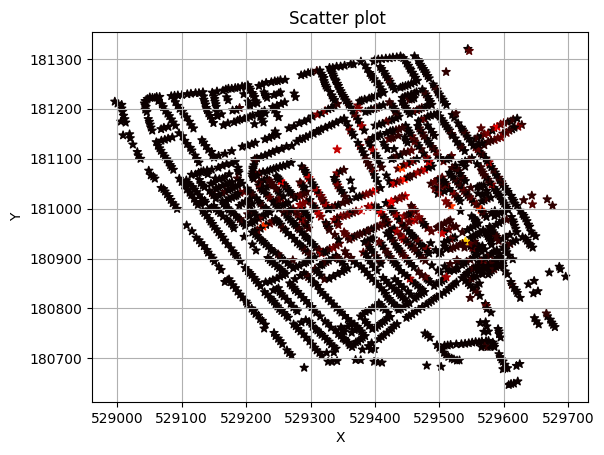

In [20]:
import matplotlib.pyplot as plt
plt.scatter(df_multivariante['COORD_X'], df_multivariante['COORD_Y'], marker="*", c=df_multivariante['deaths'], cmap='hot')
plt.grid(True)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatter plot ")
plt.plot()

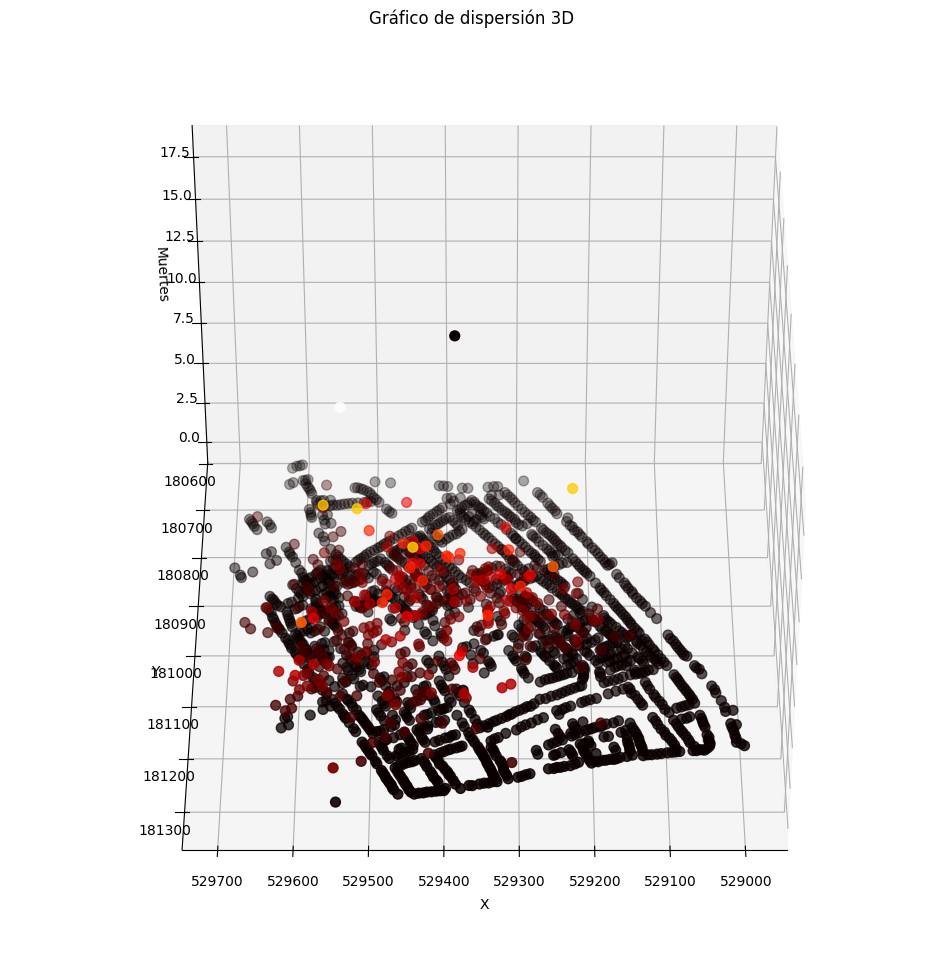

In [21]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_multivariante['COORD_X'], df_multivariante['COORD_Y'], df_multivariante['deaths'],
           c=df_multivariante['deaths_r'], cmap='hot', s=50)
ax.view_init(elev=40, azim=90)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Muertes')
plt.title('Gráfico de dispersión 3D')
plt.show()


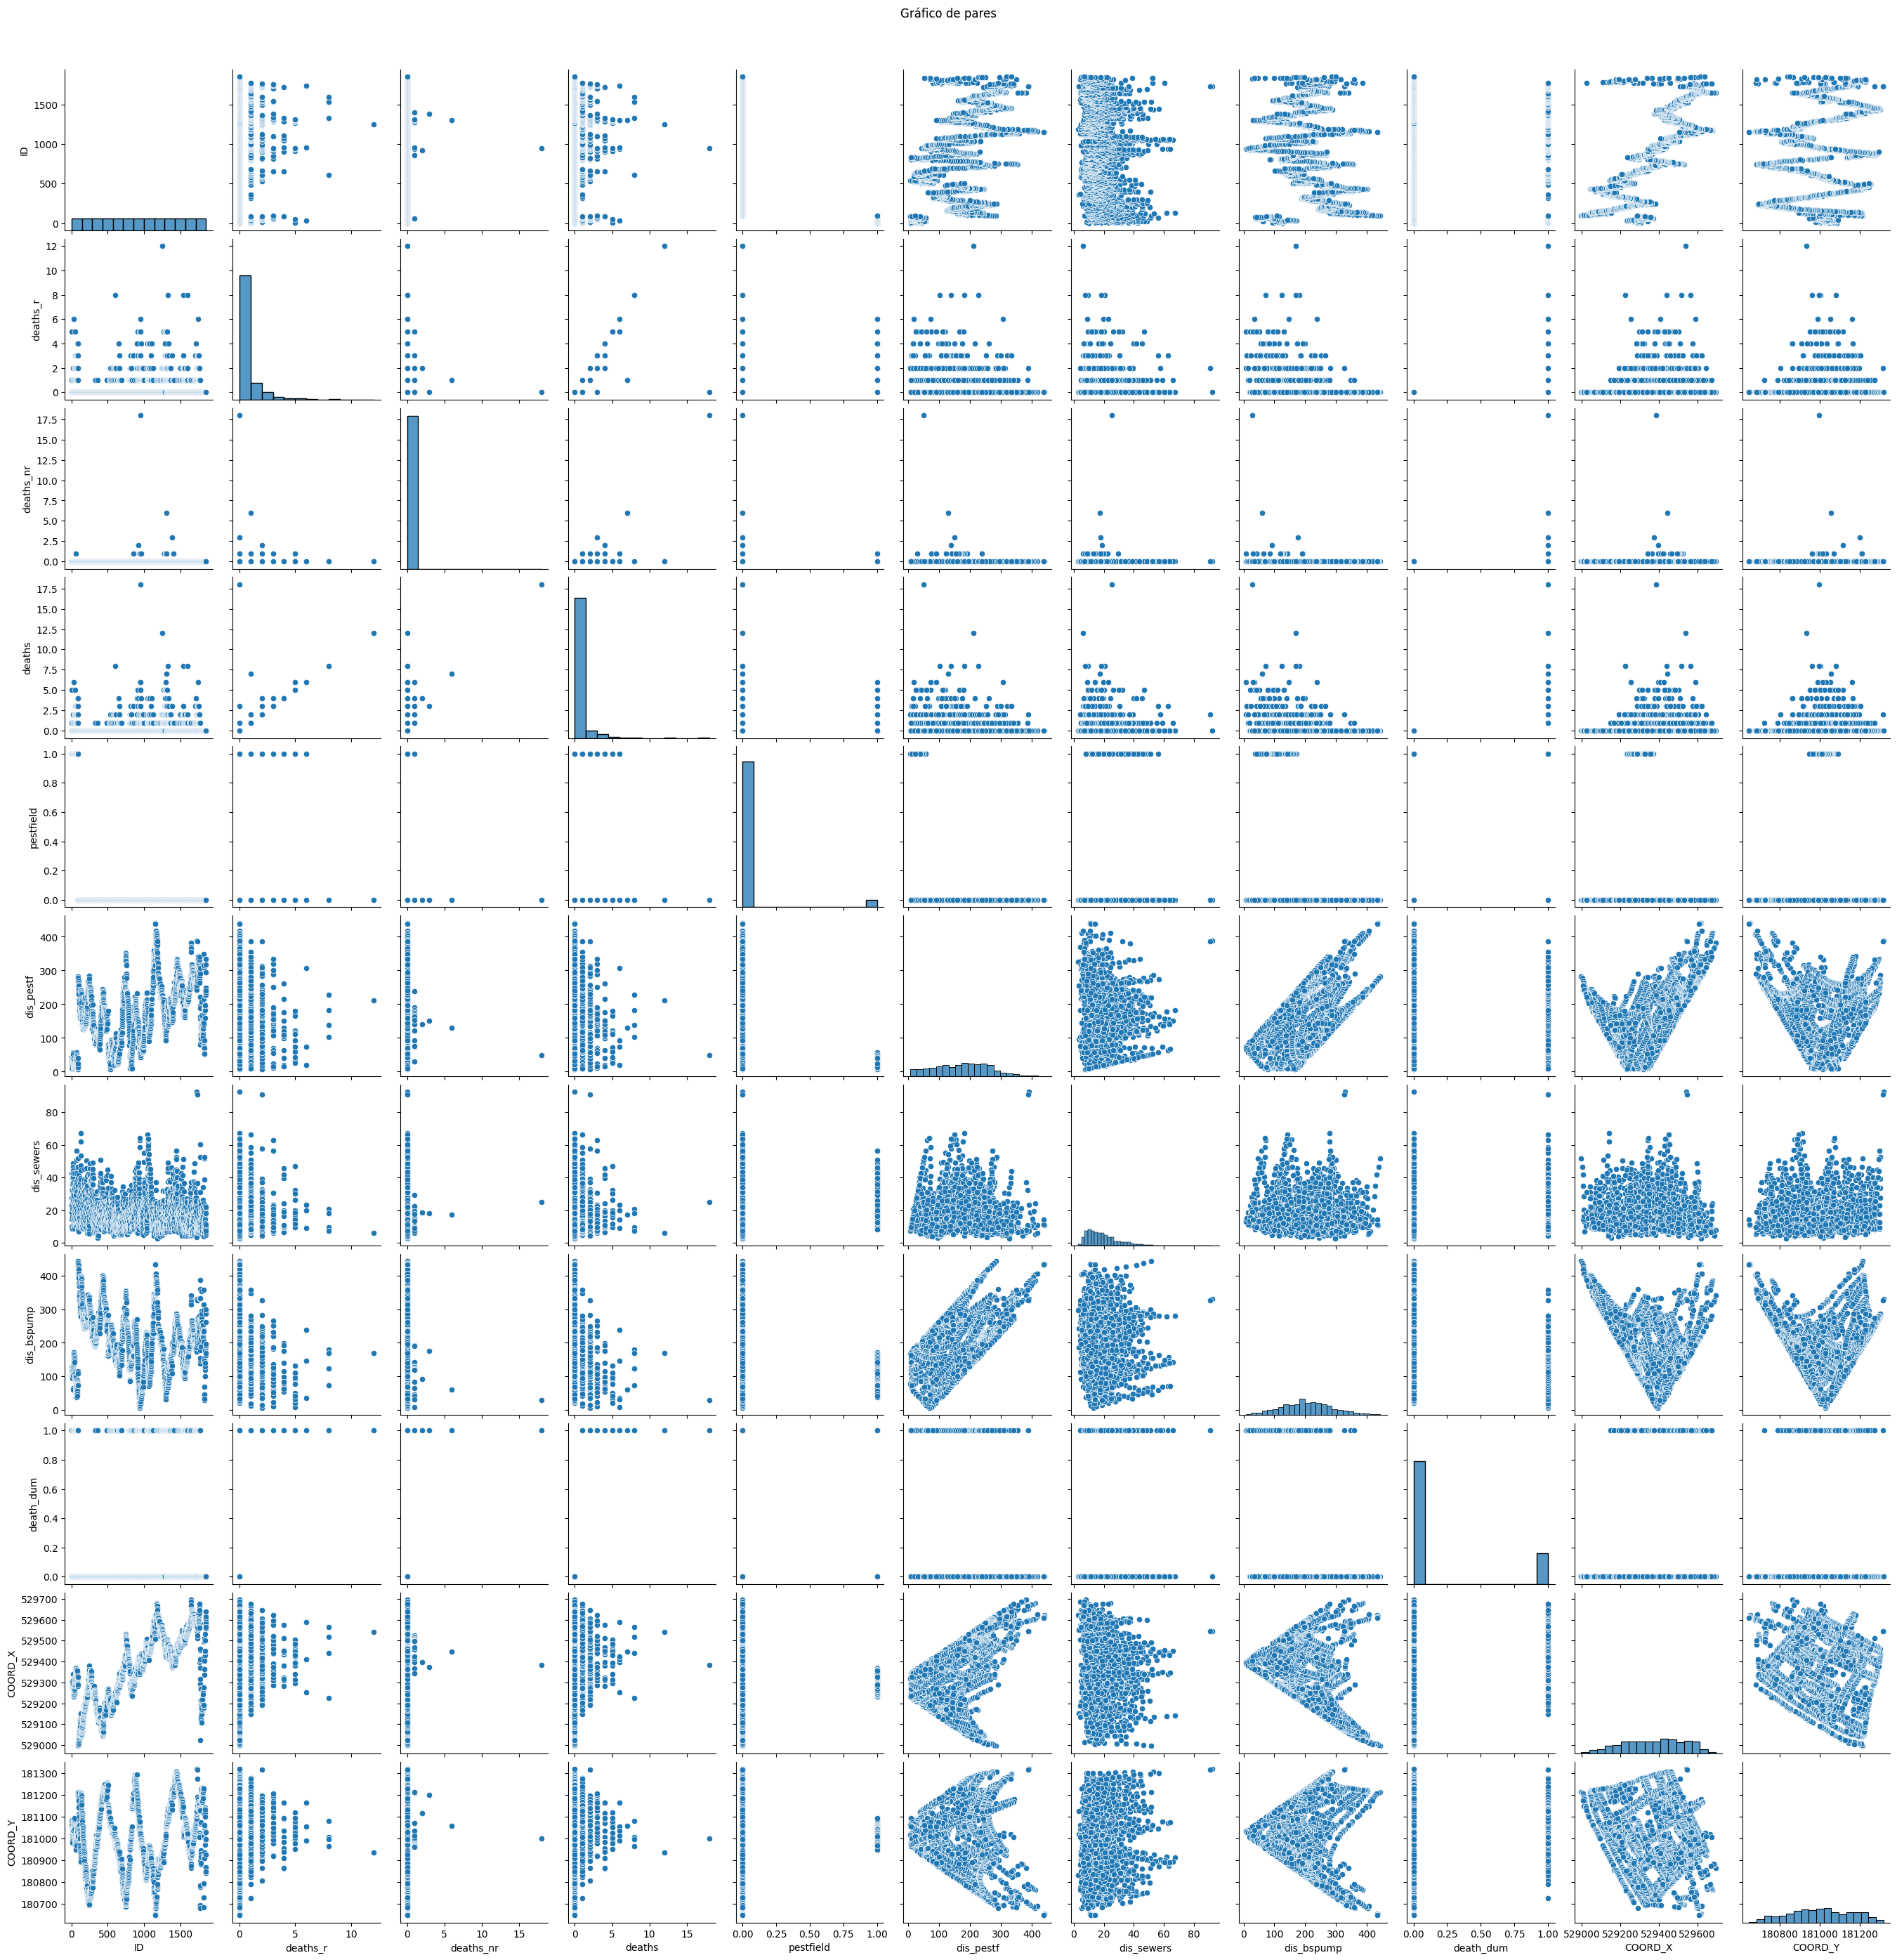

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
fig = sns.pairplot(df_multivariante)
fig.fig.suptitle('Gráfico de pares', y=1.02)
plt.show()

## Visualización de Correlaciones

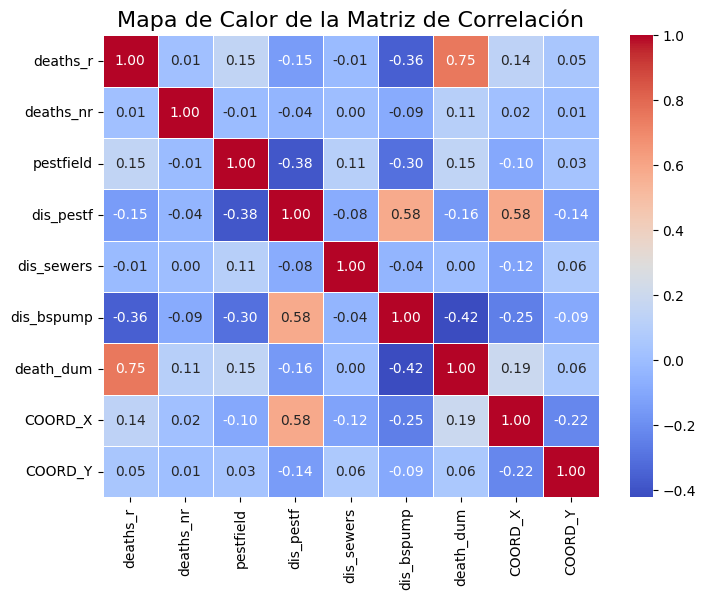

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(df_centrado.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)

# Add a title to the heatmap
plt.title('Mapa de Calor de la Matriz de Correlación', fontsize=16)

# Display the plot
plt.show()

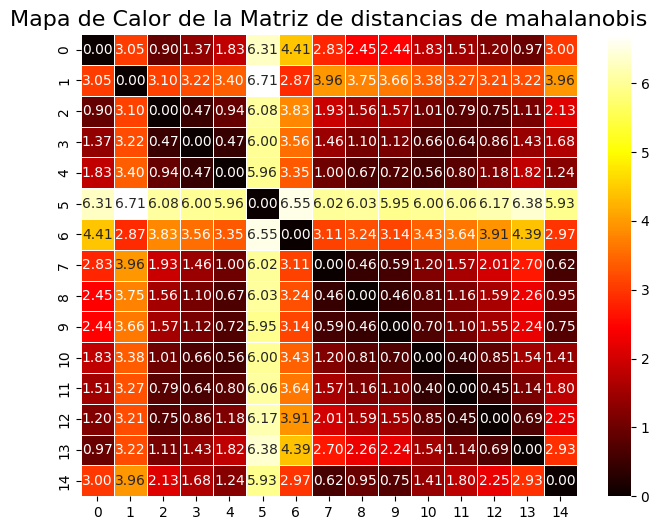

In [24]:
plt.figure(figsize=(8, 6))

sns.heatmap(mahalanobis_dist_matrix[:15, :15], annot=True, cmap='hot', fmt='.2f', linewidths=.5)

# Add a title to the heatmap
plt.title('Mapa de Calor de la Matriz de distancias de mahalanobis', fontsize=16)

# Display the plot
plt.show()

## Visualización de Caras de Chernoff


In [25]:
!python -m pip install ChernoffFace

In [26]:
from ChernoffFace import *
import numpy
import matplotlib.cm

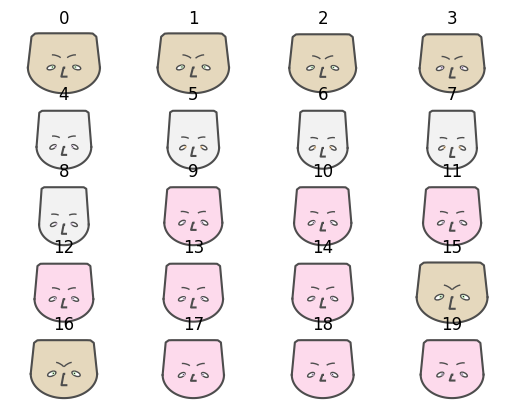

In [27]:
fig = chernoff_face(data=df_centrado.iloc[5:25, :],
                    titles=[str(x) for x in list(range(len(df_centrado.iloc[5:25, :])))],
                    color_mapper=matplotlib.cm.Pastel1)

## Visualización Geoespacial de Muertes


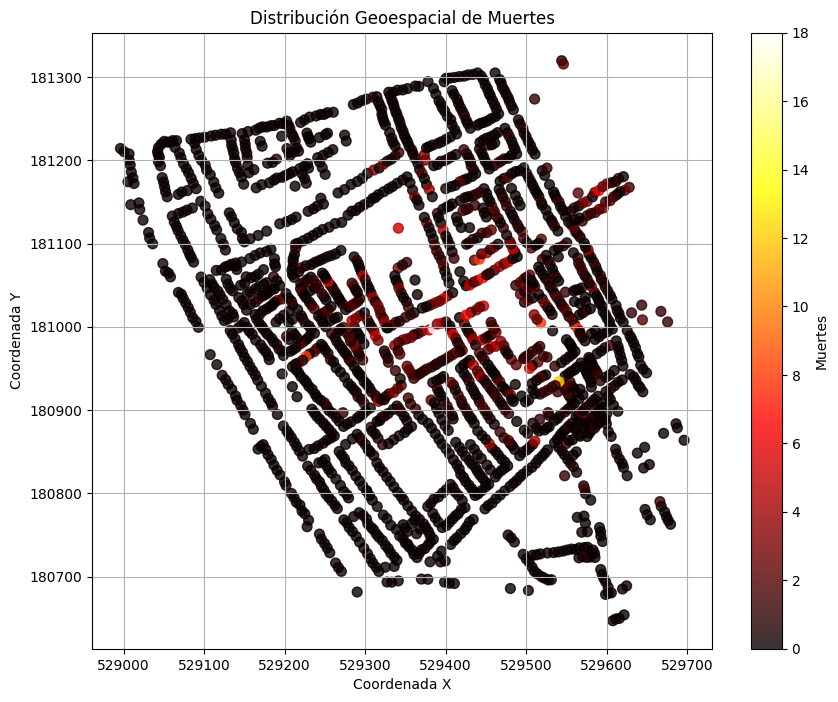

In [28]:
plt.figure(figsize=(10, 8))
plt.scatter(df_multivariante['COORD_X'], df_multivariante['COORD_Y'], c=df_multivariante['deaths'], cmap='hot', s=50, alpha=0.8)
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Distribución Geoespacial de Muertes')
plt.colorbar(label='Muertes')
plt.grid(True)
plt.show()

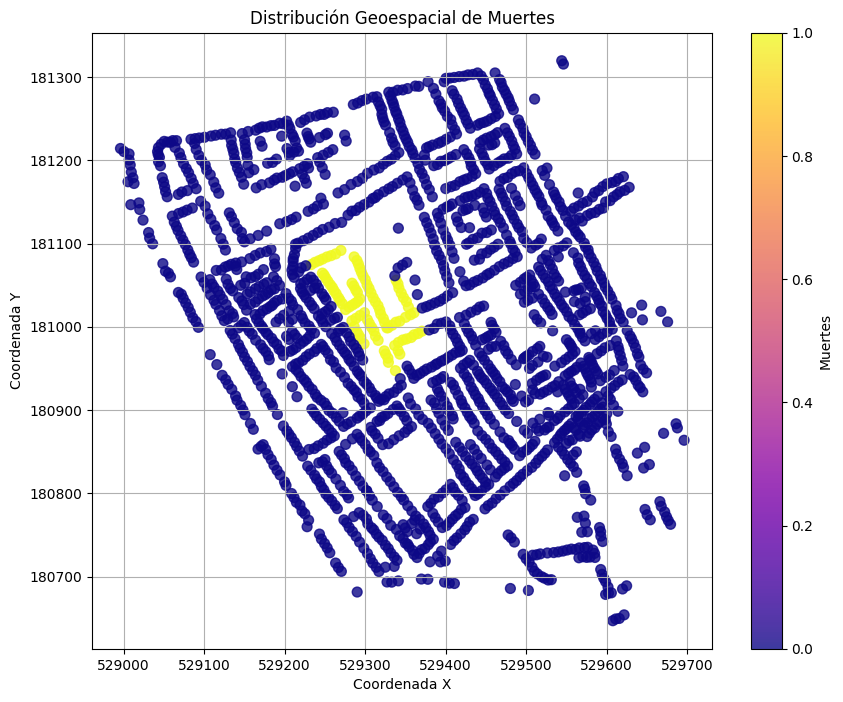

In [29]:
plt.figure(figsize=(10, 8))
plt.scatter(df_multivariante['COORD_X'], df_multivariante['COORD_Y'], c=df_multivariante['pestfield'], cmap='plasma', s=50, alpha=0.8)
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Distribución Geoespacial de Muertes')
plt.colorbar(label='Muertes')
plt.grid(True)
plt.show()

## Análisis de la relación entre muertes y fuente


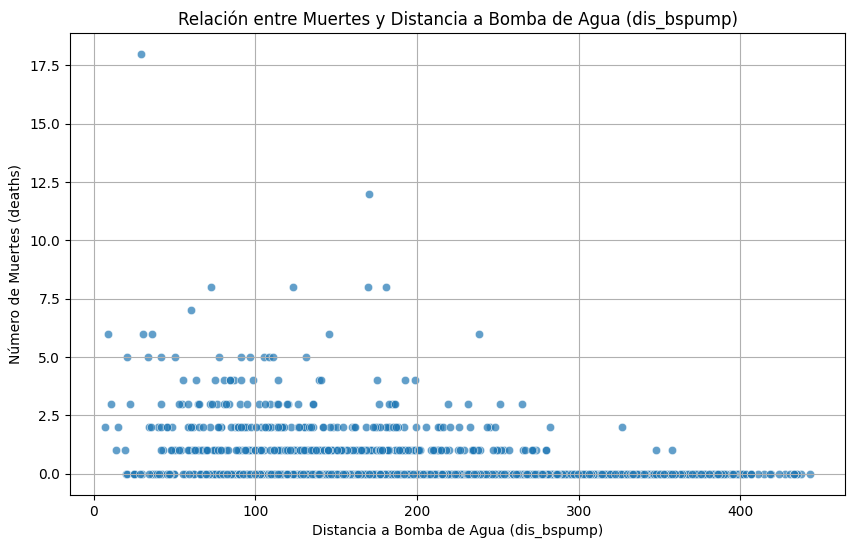

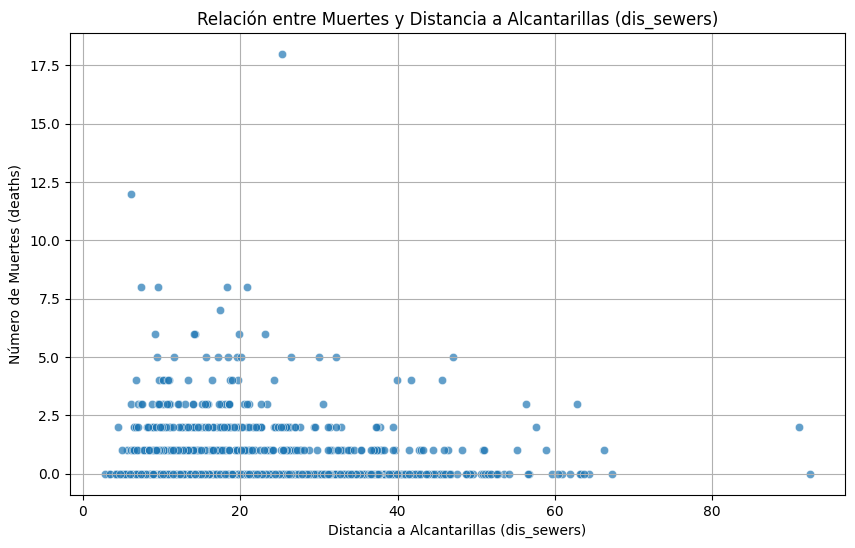

Coeficiente de Correlación entre 'deaths' y 'dis_bspump': -0.3598
Coeficiente de Correlación entre 'deaths' y 'dis_sewers': -0.0120


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_multivariante, x='dis_bspump', y='deaths', alpha=0.7)
plt.title('Relación entre Muertes y Distancia a Bomba de Agua (dis_bspump)')
plt.xlabel('Distancia a Bomba de Agua (dis_bspump)')
plt.ylabel('Número de Muertes (deaths)')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_multivariante, x='dis_sewers', y='deaths', alpha=0.7)
plt.title('Relación entre Muertes y Distancia a Alcantarillas (dis_sewers)')
plt.xlabel('Distancia a Alcantarillas (dis_sewers)')
plt.ylabel('Número de Muertes (deaths)')
plt.grid(True)
plt.show()

corr_deaths_bspump = df_multivariante['deaths'].corr(df_multivariante['dis_bspump'])
corr_deaths_sewers = df_multivariante['deaths'].corr(df_multivariante['dis_sewers'])
print(f"Coeficiente de Correlación entre 'deaths' y 'dis_bspump': {corr_deaths_bspump:.4f}")
print(f"Coeficiente de Correlación entre 'deaths' y 'dis_sewers': {corr_deaths_sewers:.4f}")

## Identificación de Puntos Críticos


In [31]:
top_5_deaths = df_multivariante.nlargest(5, 'deaths')
pump = df_multivariante.nsmallest(1, 'dis_bspump')
pestfield = df_multivariante.nsmallest(1, 'dis_pestf')
print(top_5_deaths[['ID', 'deaths', 'COORD_X', 'COORD_Y', 'dis_bspump', 'dis_sewers']])
print(pump[['ID', 'deaths', 'COORD_X', 'COORD_Y', 'dis_bspump', 'dis_sewers']])
print(pestfield[['ID', 'deaths', 'COORD_X', 'COORD_Y', 'dis_bspump', 'dis_sewers']])

        ID  deaths        COORD_X        COORD_Y  dis_bspump  dis_sewers
947    948      18  529385.184713  180998.096883       29.27       25.26
1252  1253      12  529540.442266  180934.132894      170.25        6.07
605    606       8  529226.583378  180964.115297      180.59        9.58
1330  1331       8  529441.989500  181081.412131       72.40       20.89
1536  1537       8  529518.064914  181004.785042      123.22       18.29
      ID  deaths        COORD_X        COORD_Y  dis_bspump  dis_sewers
941  942       2  529392.257111  181030.923376        7.26       13.08
      ID  deaths        COORD_X        COORD_Y  dis_bspump  dis_sewers
535  536       0  529232.574418  181059.757016      167.63        7.56


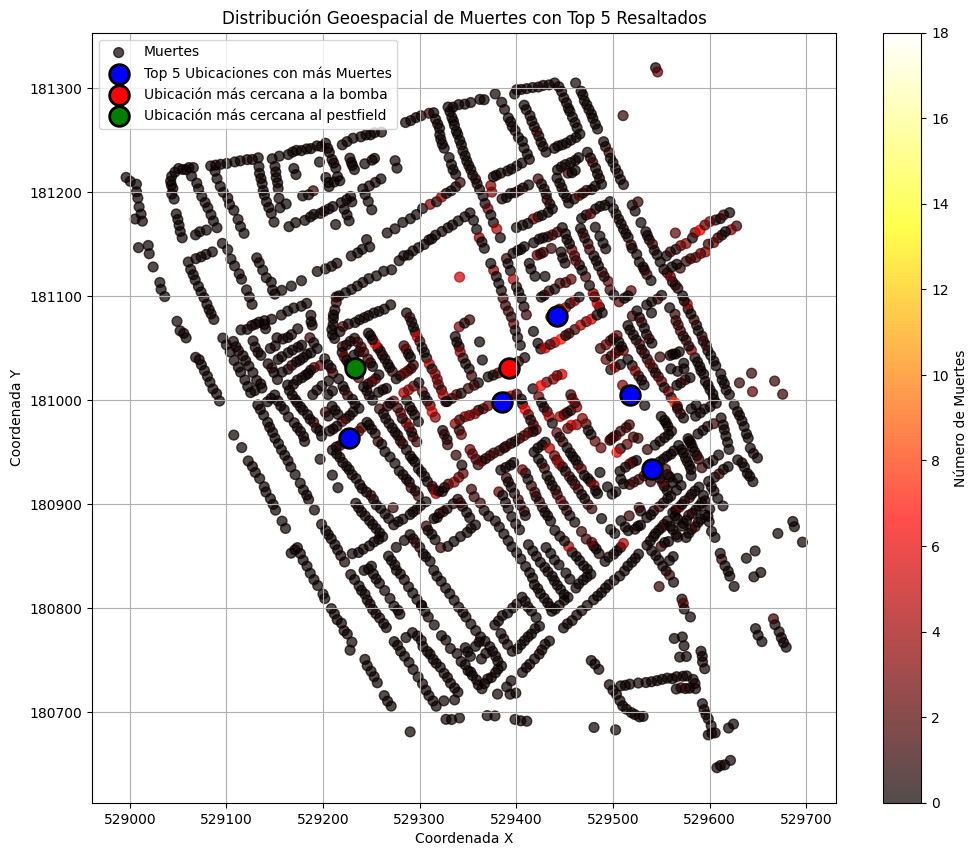

In [32]:
plt.figure(figsize=(12, 10))

# Plot all locations, colored by deaths
scatter_all = plt.scatter(df_multivariante['COORD_X'], df_multivariante['COORD_Y'],
                            c=df_multivariante['deaths'], cmap='hot', s=50, alpha=0.7,
                            label='Muertes')

# Overlay and highlight the top 5 death locations
plt.scatter(top_5_deaths['COORD_X'], top_5_deaths['COORD_Y'],
            color='blue', marker='o', s=200, edgecolor='black', linewidth=2,
            label='Top 5 Ubicaciones con más Muertes')
plt.scatter(pump['COORD_X'], pump['COORD_Y'],
            color='red', marker='o', s=200, edgecolor='black', linewidth=2,
            label='Ubicación más cercana a la bomba')
plt.scatter(pestfield['COORD_X'], pump['COORD_Y'],
            color='g', marker='o', s=200, edgecolor='black', linewidth=2,
            label='Ubicación más cercana al pestfield')

# Add labels and title
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Distribución Geoespacial de Muertes con Top 5 Resaltados')

# Add colorbar for general deaths
plt.colorbar(scatter_all, label='Número de Muertes')

# Add legend for highlighted points
plt.legend()

plt.grid(True)
plt.show()



**Análisis de la Relación:**

*   **Relación con `dis_bspump`:** El coeficiente de correlación entre 'deaths' y 'dis_bspump' es de **-0.3598**. Esto indica una correlación negativa moderada, lo que sugiere que a menor distancia a la bomba principal, mayor tiende a ser el número de muertes. La ubicación con más muertes (ID 948) está relativamente cerca de la bomba, reforzando esta idea.
*   **Relación con `dis_sewers`:** El coeficiente de correlación entre 'deaths' y 'dis_sewers' es de **-0.0120**. Esta correlación es muy débil y prácticamente nula. Sin embargo, al observar los puntos críticos, notamos que varias de las ubicaciones con muchas muertes tienen distancias bajas a las alcantarillas (e.g., ID 1253 con 6.07, ID 606 con 9.58). Esto sugiere que, si bien la correlación general puede ser baja, la proximidad a las alcantarillas podría ser un factor local importante en ciertos puntos de alta mortalidad.




**Identificación de Puntos Críticos y Fuentes Potenciales:**

El gráfico de dispersión geoespacial con los puntos de alta mortalidad resaltados visualiza claramente una concentración de muertes. Aunque no se observa una única "bomba de Broad Street" con un dominio absoluto en todas las muertes, hay indicaciones de que la proximidad a ciertas fuentes, especialmente la bomba principal (`dis_bspump`), está relacionada con una mayor incidencia de muertes. La ubicación con más muertes (ID 948) se encuentra relativamente cerca de la bomba, similar a cómo Snow identificó la bomba de Broad Street.

Los puntos críticos con altas muertes y baja `dis_sewers` (como ID 1253 y 606) sugieren que la infraestructura de saneamiento, o su cercanía, también podría ser un factor contribuyente, emulando la investigación de Snow sobre la contaminación de pozos negros.

**Conclusión y Comparación con John Snow:**

Nuestro análisis, aunque con un conjunto de datos diferente, emula con éxito la metodología de John Snow al:
1.  **Visualizar la distribución espacial de las muertes:** Permitiendo identificar clusters de alta mortalidad.
2.  **Correlacionar muertes con fuentes potenciales:** Mostrando una correlación negativa moderada con la bomba principal (`dis_bspump`), lo que implica que la cercanía a esta fuente está asociada con más muertes. La correlación con `dis_sewers` es débil en general, pero los puntos críticos muestran cercanía.
3.  **Identificar puntos críticos:** Resaltando ubicaciones específicas que requieren una investigación más profunda debido a su alta tasa de mortalidad y su proximidad a las fuentes.

Similar al trabajo de Snow, este análisis geoespacial y de proximidad proporciona una base empírica para formular hipótesis sobre las causas de las muertes y dónde dirigir las intervenciones. La diferencia clave es que, en este caso, la señal de la "fuente de contaminación" no es tan abrumadoramente obvia como la bomba de Broad Street en el trabajo original de Snow, pero los patrones y las correlaciones aún guían hacia posibles factores.